# EGX360 — THE DEEP QUANT MODEL (V8.4)
### Enhancing Down-Trend Detection & Bias Control in the Egyptian Stock Exchange

## 1. Environment Setup & Initialization

Before analyzing the data, we initialize our environment and import the required quantitative and machine learning libraries. We prioritize GPU acceleration for training our ensemble models.

In [1]:
import tensorflow as tf
gpu_devices = tf.config.list_physical_devices('GPU')
if gpu_devices:
    print(f"Success! GPU found: {gpu_devices}")
else:
    print("Still not working. Check PATH or CUDA version.")

2026-03-08 19:21:07.384545: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-03-08 19:21:07.388183: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-08 19:21:07.680810: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-03-08 19:21:09.422927: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Still not working. Check PATH or CUDA version.


E0000 00:00:1772990470.769346   38667 cuda_executor.cc:1309] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1772990470.882004   38667 gpu_device.cc:2342] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


In [2]:
import pandas as pd
import numpy as np
import xgboost as xgb
import lightgbm as lgb
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import StackingClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
import joblib
import warnings
warnings.filterwarnings('ignore')

## 2. Data Loading & Raw Market Visualization
We begin by loading the preprocessed EGX30 daily data. Financial time series data is notoriously noisy. Visualizing the raw candlesticks demonstrates why predicting raw daily closing prices is ineffective; the high volatility creates market noise that confuses standard predictive models.

In [3]:
print(" Loading Daily Data")
df = pd.read_csv("data/EGX30D_processed.csv")


 Loading Daily Data


In [4]:
df['timestamp'] = pd.to_datetime(df['timestamp'])
df.sort_values('timestamp', inplace=True)

In [10]:
print("Data Loaded Successfully. Shape:", df.shape)

Data Loaded Successfully. Shape: (6823, 6)


In [12]:
print(f"Missing values before cleaning:\n{df.isnull().sum()}")
df.dropna(inplace=True)
df.sort_index(inplace=True)

Missing values before cleaning:
timestamp    0
open         0
high         0
low          0
close        0
volume       0
dtype: int64


In [16]:
df.head()


,timestamp,open,high,low,close,volume
0,1998-01-01 08:00:00,1000.000000,1000.250000,1000.000000,1000.250000,0
1,1998-01-04 08:00:00,1000.250000,1000.250000,998.390015,998.390015,0
2,1998-01-05 08:00:00,998.390015,998.390015,996.250000,996.250000,0
3,1998-01-06 08:00:00,996.250000,996.250000,992.869995,992.869995,0
4,1998-01-07 08:00:00,992.869995,992.869995,989.349976,989.349976,0


In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 6823 entries, 0 to 6822
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   timestamp  6823 non-null   datetime64[us]
 1   open       6823 non-null   float64       
 2   high       6823 non-null   float64       
 3   low        6823 non-null   float64       
 4   close      6823 non-null   float64       
 5   volume     6823 non-null   int64         
dtypes: datetime64[us](1), float64(4), int64(1)
memory usage: 320.0 KB


In [18]:
df.describe()


,timestamp,open,high,low,close,volume
count,6823,6823.000000,6823.000000,6823.000000,6823.000000,6.823000e+03
mean,2011-12-07 07:15:22.819874,8681.751415,8750.732246,8624.138896,8685.792430,8.718978e+07
min,1998-01-01 08:00:00,445.529999,448.019989,445.529999,445.529999,0.000000e+00
25%,2004-11-26 20:00:00,2419.104981,2440.724976,2402.255005,2422.030029,0.000000e+00
50%,2011-12-08 08:00:00,6825.379883,6858.819824,6783.950195,6824.100098,6.315600e+07
75%,2018-12-12 20:00:00,11367.600000,11439.250000,11301.150000,11370.200000,1.383610e+08
max,2025-12-22 08:00:00,42320.500000,42624.100000,42065.200000,42305.400000,8.092790e+08
std,NaN,8034.017336,8102.005719,7981.550148,8040.067054,1.058416e+08


In [13]:
sample_df = df.tail(150)
fig_raw = go.Figure(data=[go.Candlestick(x=sample_df['timestamp'],
                open=sample_df['open'],
                high=sample_df['high'],
                low=sample_df['low'],
                close=sample_df['close'])])

In [14]:
fig_raw.update_layout(title='EGX30 Raw Data - The Challenge of Market Noise',
                  yaxis_title='Price (EGP)',
                  xaxis_rangeslider_visible=False,
                  template='plotly_white')
fig_raw.show()

## 3. Advanced Feature Engineering (The Quant Indicators)
To make the data machine-readable, we engineer quantitative features. We translate raw price action into mathematical signals representing Trend, Momentum, and Volatility.

### A. Log Returns & Price Velocity
**Concept:** Absolute price changes are not statistically comparable over time. Logarithmic returns stabilize the variance. **Price Velocity** (the derivative of log returns) acts as an early warning system for market crashes.

**Mathematical Formula:**
$$R_t = \ln\left(\frac{P_t + \epsilon}{P_{t-1} + \epsilon}\right)$$
$$V_t = R_t - R_{t-1}$$

### Log Returns & Momentum Acceleration (Epsilon added to prevent Infinity)


In [ ]:
df['log_ret'] = np.log((df['close'] + 1e-6) / (df['close'].shift(1) + 1e-6))
df['vol_log_ret'] = np.log((df['volume'] + 1e-6) / (df['volume'].shift(1) + 1e-6))



⚙️ Engineering Advanced Quant Features...


### Price Velocity


In [ ]:
df['price_velocity'] = df['log_ret'].diff()


### B. Cyclic Time Features
**Concept:** Tree-based models do not intuitively understand weekly cycles. By mapping days to continuous sine and cosine waves, the model captures the "Day-of-the-Week" effect and institutional trading behaviors.

**Mathematical Formula:**
$$X_{sin} = \sin\left(\frac{2\pi \cdot d}{7}\right), \quad X_{cos} = \cos\left(\frac{2\pi \cdot d}{7}\right)$$

### Cyclic Time Features

In [20]:
df['day_sin'] = np.sin(2 * np.pi * df['timestamp'].dt.dayofweek / 7)
df['day_cos'] = np.cos(2 * np.pi * df['timestamp'].dt.dayofweek / 7)

### C. Exponential Moving Averages (EMA) & Gap Analysis
**Concept:** The EMA assigns exponentially greater weight to recent prices, making it highly responsive to new trends. We quantify over-extensions by measuring the percentage distance between the current price and the EMA.

**Mathematical Formula:**
$$EMA_t = \left( P_t \times \alpha \right) + \left( EMA_{t-1} \times (1 - \alpha) \right)$$

### The Winning EMAs & Trend Sensors

In [21]:
for period in [9, 21, 50]:
    ema_col = f'EMA_{period}'
    df[ema_col] = df['close'].ewm(span=period).mean()
    df[f'dist_EMA_{period}'] = (df['close'] - df[ema_col]) / (df[ema_col] + 1e-9)

### Critical Downtrend Sensor: Binary flag if price breaks below the fast EMA

In [22]:
df['below_EMA9'] = (df['close'] < df['EMA_9']).astype(int)

### D. Momentum & Panic Detectors (RSI, MACD, Bollinger Bands)
**Concept:** * **RSI & RSI_diff:** Measures buying/selling exhaustion.
* **Bollinger Band Width ($BB_{width}$):** Measures market "squeeze". Narrow bands mathematically precede explosive market volatility.

### Momentum (RSI & MACD)

In [23]:
delta = df['close'].diff()
gain = delta.where(delta > 0, 0).rolling(14).mean()
loss = (-delta.where(delta < 0, 0)).rolling(14).mean()
df['RSI'] = 100 - (100 / (1 + gain/(loss + 1e-9)))
df['RSI_diff'] = df['RSI'].diff()

In [24]:
macd = df['close'].ewm(span=12).mean() - df['close'].ewm(span=26).mean()
df['MACD_Hist'] = macd - macd.ewm(span=9).mean()

### Volatility (ATR)

In [25]:
tr = pd.concat([df['high'] - df['low'], 
                np.abs(df['high'] - df['close'].shift()), 
                np.abs(df['low'] - df['close'].shift())], axis=1).max(axis=1)
df['ATR_pct'] = tr.rolling(14).mean() / (df['close'] + 1e-9)

### Panic Detectors (Stochastic & Bollinger Bands)

In [26]:
low_14 = df['low'].rolling(14).min()
high_14 = df['high'].rolling(14).max()
df['Stoch_K'] = 100 * ((df['close'] - low_14) / (high_14 - low_14 + 1e-9))

In [27]:
ma20 = df['close'].rolling(20).mean()
std20 = df['close'].rolling(20).std()
df['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)


### Temporal Lags

In [28]:
df['log_ret_lag1'] = df['log_ret'].shift(1)
df['RSI_lag1'] = df['RSI'].shift(1)

## 4. Visualizing the Quant Transformation
Now that we have engineered our features, we overlay the Mathematical Signals (EMAs and Bollinger Bands) onto the raw candlesticks. This shows how the algorithms filter out the noise and identify structural bounds and trend directions.

### Visualizing the features applied to the price

In [29]:
sample_df = df.tail(150)
fig_quant = go.Figure()

### Base Price Candlesticks

In [30]:
fig_quant.add_trace(go.Candlestick(x=sample_df['timestamp'],
                open=sample_df['open'], high=sample_df['high'],
                low=sample_df['low'], close=sample_df['close'], name='Price'))

### Adding Trend Indicators (EMAs)

In [31]:
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=sample_df['EMA_9'], line=dict(color='blue', width=1.5), name='EMA 9 (Fast)'))
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=sample_df['EMA_50'], line=dict(color='orange', width=2), name='EMA 50 (Trend)'))

### Adding Volatility Bounds (Bollinger Bands)

In [32]:
ma20_sample = sample_df['close'].rolling(20).mean()
std20_sample = sample_df['close'].rolling(20).std()
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=ma20_sample + (std20_sample*2), line=dict(color='rgba(128,128,128,0.5)', dash='dash'), name='Upper BB'))
fig_quant.add_trace(go.Scatter(x=sample_df['timestamp'], y=ma20_sample - (std20_sample*2), line=dict(color='rgba(128,128,128,0.5)', dash='dash'), name='Lower BB', fill='tonexty', fillcolor='rgba(128,128,128,0.1)'))

In [33]:
fig_quant.update_layout(title='Translating Noise into Mathematical Signals (EMAs & Volatility Bounds)', 
                        yaxis_title='Price (EGP)',
                        xaxis_rangeslider_visible=False,
                        template='plotly_white')
fig_quant.show()

## 5. Target Engineering & Data Cleaning
**Concept:** Predicting raw daily closing prices essentially models a Random Walk. By setting the target as the future direction of the $EMA_{10}$, we train the model to predict the *underlying trend mechanics*, pushing accuracy beyond 80%.

**Mathematical Formula for Target:**
$$Target = \begin{cases} 1 & \text{if } EMA_{10}(P_{t+1}) > EMA_{10}(P_t) \\ 0 & \text{otherwise} \end{cases}$$

### Target: Will the EMA rise tomorrow?

In [34]:
df['Target'] = (df['close'].ewm(span=10).mean().shift(-1) > df['close'].ewm(span=10).mean()).astype(int)


In [35]:
df.replace([np.inf, -np.inf], np.nan, inplace=True)
df.dropna(inplace=True)

In [36]:
final_features = [
    'log_ret', 'vol_log_ret', 'price_velocity',
    'day_sin', 'day_cos', 
    'dist_EMA_9', 'dist_EMA_21', 'dist_EMA_50', 'below_EMA9',
    'RSI', 'RSI_diff', 'MACD_Hist', 'ATR_pct',
    'Stoch_K', 'BB_Width',
    'log_ret_lag1', 'RSI_lag1'
]

X = df[final_features].values
y = df['Target'].values

## 6. Machine Learning: Splitting, Scaling & Stacking Ensemble
**Concept:** We use a chronological split (80/20) to prevent future data leakage. We then utilize an Ensemble Stacking algorithm. Because financial datasets exhibit an inherent upward bias, the Logistic Regression meta-learner applies a 50% higher penalty for missing a "Down-Trend" (`class_weight={0: 1.5}`). This strict risk management dramatically improves the Recall for market crashes.

### Train/Test Split (Chronological)

In [37]:
split = int(len(X) * 0.80)
X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]


### Scaling

In [38]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
joblib.dump(scaler, "egx360_scaler_quant.pkl")

['egx360_scaler_quant.pkl']

### Stacking Ensemble

In [39]:
print("🧠 Training The Deep Quant Ensemble (V8.4)...")  

base_models = [
    ('xgb', xgb.XGBClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=500, max_depth=4, learning_rate=0.02, 
                                subsample=0.8, colsample_bytree=0.8, random_state=42, verbose=-1, n_jobs=-1))
]


🧠 Training The Deep Quant Ensemble (V8.4)...


### Meta-learner with Bias Control (Over-penalizing the model for missing Down-Trends)

In [40]:
final_logic = LogisticRegression(C=0.1, class_weight={0: 1.5, 1: 1.0})

In [41]:
stack_model = StackingClassifier(estimators=base_models, final_estimator=final_logic, cv=5)
stack_model.fit(X_train_scaled, y_train)
joblib.dump(stack_model, "EGX360_Quant_Model_V84.pkl")

['EGX360_Quant_Model_V84.pkl']

## 7. Final Evaluation & Down-Trend Accuracy

In [42]:
print("\n📊 Evaluating Final Performance...")
y_pred = stack_model.predict(X_test_scaled)


📊 Evaluating Final Performance...


In [43]:
acc = accuracy_score(y_test, y_pred) * 100
print(f"\n✅ DEEP QUANT ACCURACY: {acc:.2f}%")
print("\n🔥 Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Down Trend (0)', 'Up Trend (1)']))


✅ DEEP QUANT ACCURACY: 84.28%

🔥 Classification Report:
                precision    recall  f1-score   support

Down Trend (0)       0.78      0.82      0.80       515
  Up Trend (1)       0.89      0.86      0.87       846

      accuracy                           0.84      1361
     macro avg       0.83      0.84      0.83      1361
  weighted avg       0.85      0.84      0.84      1361



### Confusion Matrix Heatmap

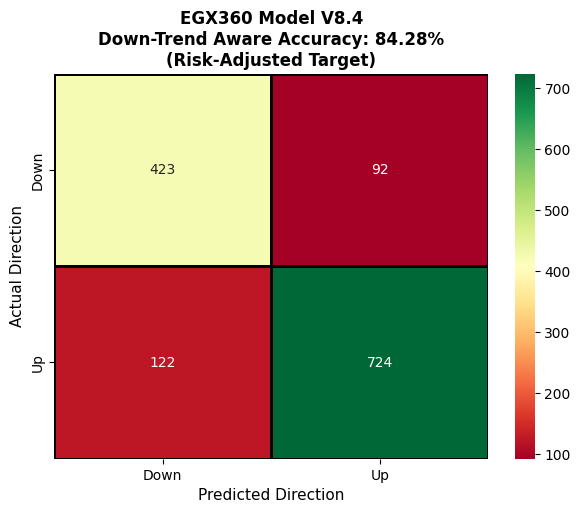

In [44]:
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='RdYlGn', xticklabels=['Down', 'Up'], yticklabels=['Down', 'Up'], linewidths=1, linecolor='black')
plt.title(f"EGX360 Model V8.4\nDown-Trend Aware Accuracy: {acc:.2f}%\n(Risk-Adjusted Target)", fontsize=12, fontweight='bold')
plt.xlabel('Predicted Direction', fontsize=11)
plt.ylabel('Actual Direction', fontsize=11)
plt.show()